In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient
from collections import defaultdict
import json
from bson import ObjectId

# MongoDB connection
client = MongoClient('mongodb://localhost:27017/')
db = client['MAC_SC']

phase1_col = db['destination, phase_1']
phase2_col = db['destination, phase_2']

# Target MAC
TARGET_MAC = '023c03d8dfd3e9f5ba101ac681ec00d01c727428a1a5969ae817120958045b74'

# Number of bins
n_bins = 40

# Load all phase_2 documents
phase2_docs = list(phase2_col.find({}))

# Build a result list
results = []

def clean_config(config):
    return {
        k: str(v) if isinstance(v, ObjectId) else v
        for k, v in config.items()
    }

# for doc2 in phase2_docs:
#     phase1_id = doc2.get('phase1_document_id')
#     if not phase1_id:
#         continue  # Skip if no linked phase1
    
#     doc1 = phase1_col.find_one({'_id': phase1_id})
#     if not doc1:
#         continue  # Skip if no matching phase1 document

#     entry = {
#         'config': doc2.get('config'),
#         'MAC': doc2.get('MAC'),
#         'SNR_phase1': doc1.get('SNR')
#     }
#     results.append(entry)

for doc2 in phase2_docs:
    phase1_id = doc2.get('phase1_document_id')
    if not phase1_id:
        continue
    
    doc1 = phase1_col.find_one({'_id': phase1_id})
    if not doc1:
        continue

    entry = {
        'MAC': doc2.get('MAC'),
        'config': doc2.get('config'),
        'SNR_phase1': doc1.get('SNR'),
        'time_phase1': doc1.get('time')  # <-- Add the time field
    }
    results.append(entry)

# Group by config
grouped = defaultdict(lambda: {'success_snrs': [], 'fail_snrs': [], 'total_messages': 0})

def clean_config(config):
    return {
        k: str(v) if isinstance(v, ObjectId) else v
        for k, v in config.items()
    }








for entry in results:
    config_clean = clean_config(entry['config'])
    config_key = json.dumps(config_clean, sort_keys=True)
    config_key = json.dumps(config_clean, sort_keys=True)
    snr = entry['SNR_phase1']
    if snr is None:
        continue
    
    grouped[config_key]['total_messages'] += 1
    if entry['MAC'] == TARGET_MAC:
        grouped[config_key]['success_snrs'].append(snr)
    else:
        grouped[config_key]['fail_snrs'].append(snr)

# Now sort configurations by total number of messages
sorted_configs = sorted(grouped.items(), key=lambda x: x[1]['total_messages'], reverse=True)

# Keep only top 2



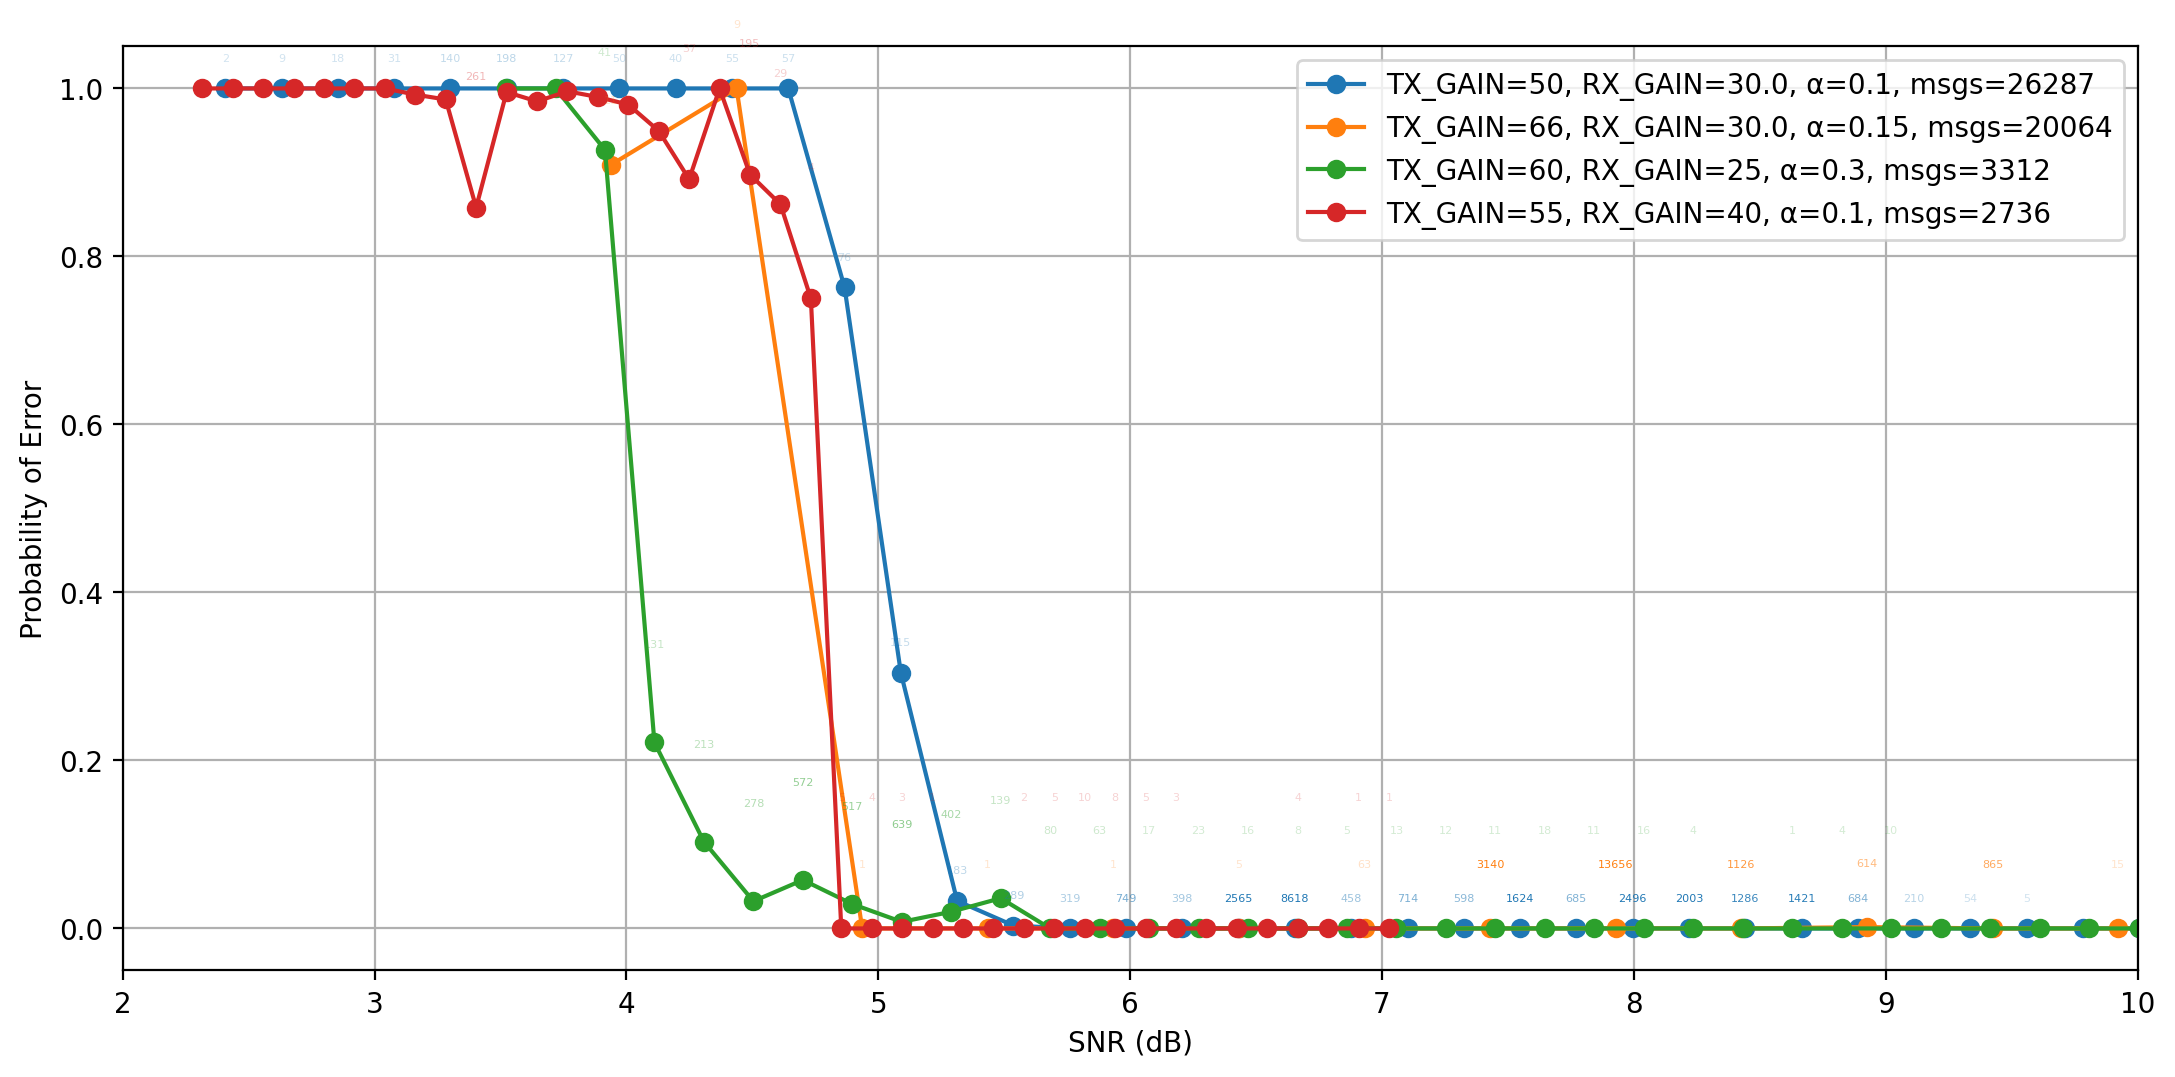

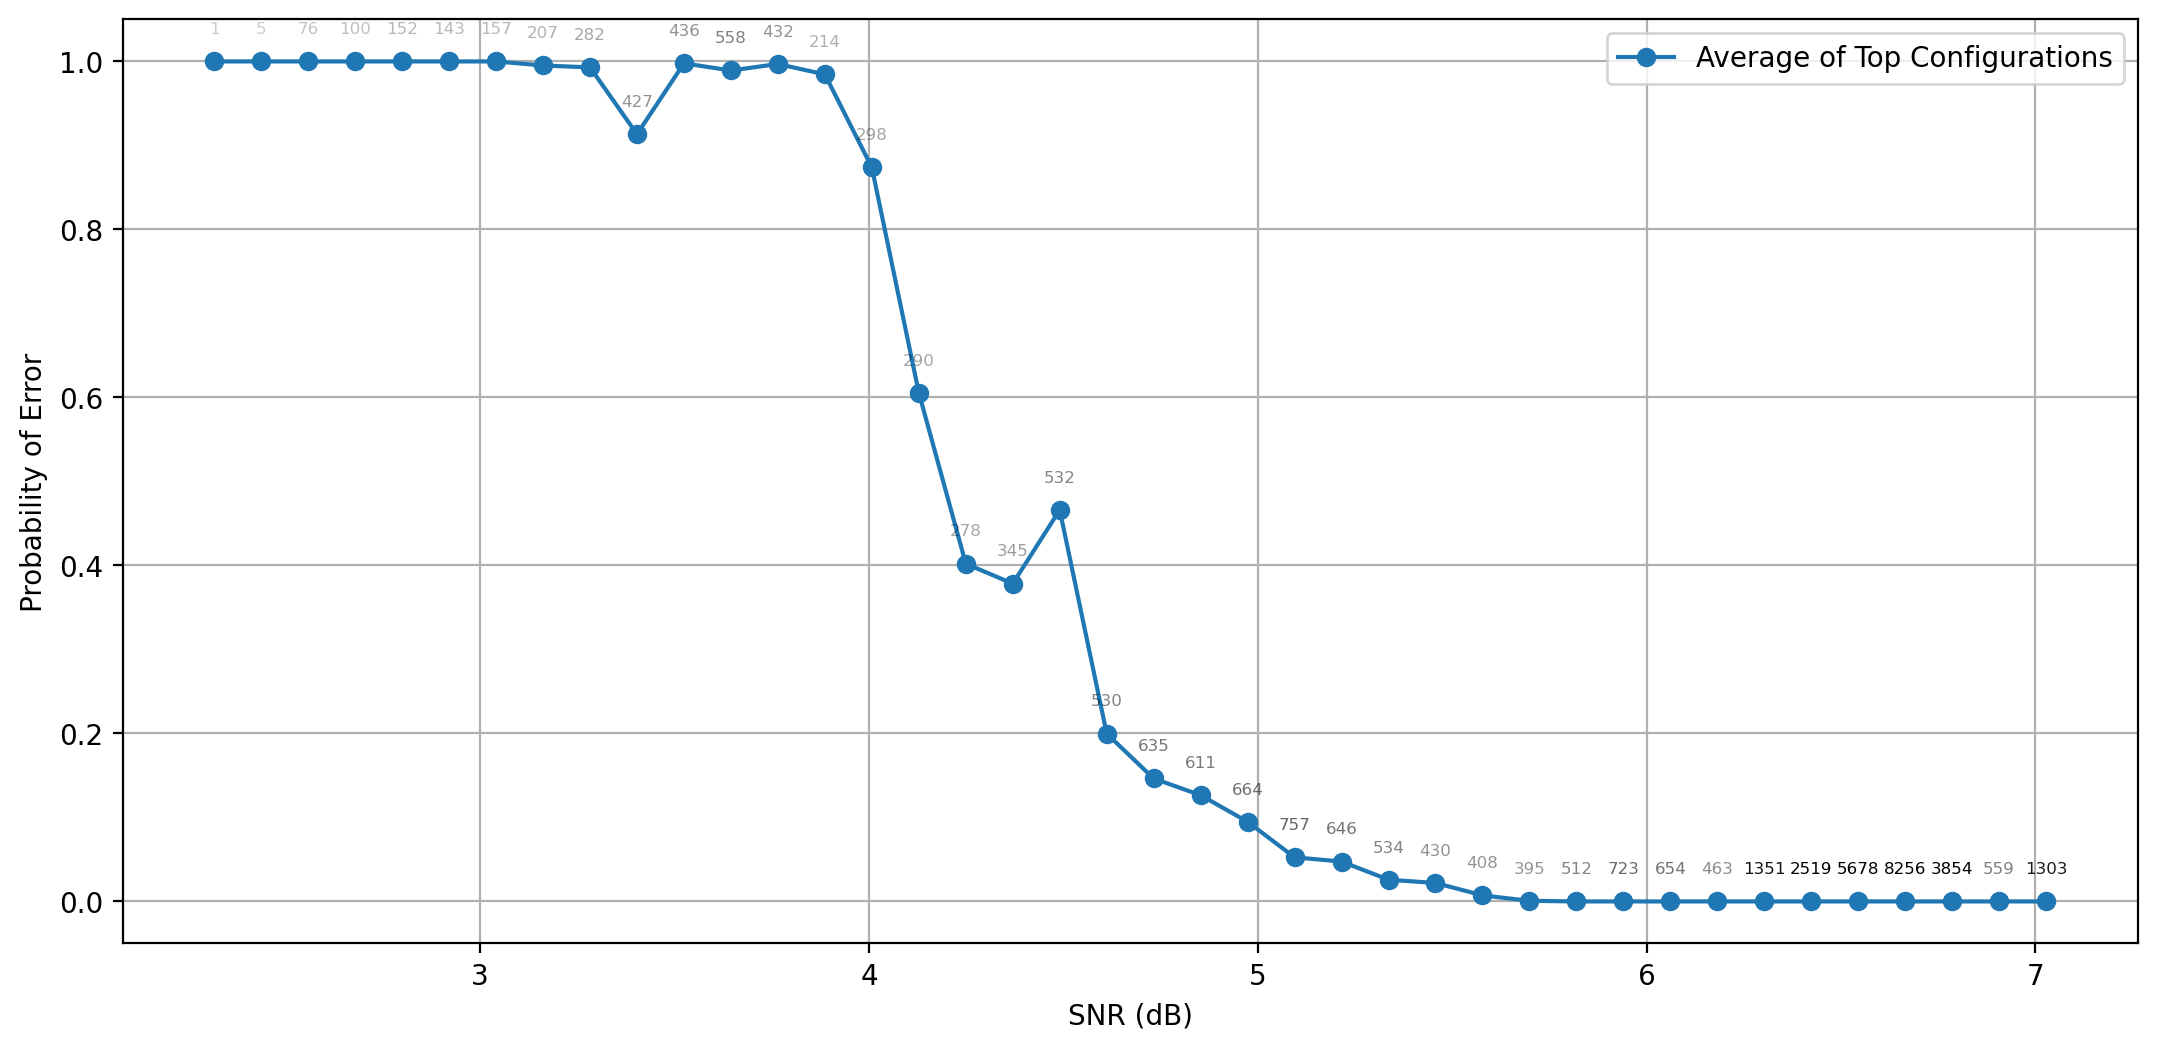

In [26]:
top_configs = [config for i, config in enumerate(sorted_configs[:7]) if i not in (2,4, 6)]

# Plot
plt.figure(figsize=(13, 6), dpi=200)
cnt = 0
for config_json, data in top_configs:
    if data['total_messages'] < 100:
        continue  # Still enforce min 100 messages

    success_snrs = np.array(data['success_snrs'])
    fail_snrs = np.array(data['fail_snrs'])
    all_snrs = np.concatenate((success_snrs, fail_snrs))

    if len(all_snrs) == 0:
        continue

    min_snr = all_snrs.min()
    max_snr = all_snrs.max()

    bins = np.linspace(min_snr, max_snr, n_bins + 1)

    success_hist, _ = np.histogram(success_snrs, bins=bins)
    fail_hist, _ = np.histogram(fail_snrs, bins=bins)

    total_hist = success_hist + fail_hist
    error_prob = np.zeros_like(total_hist, dtype=float)

    with np.errstate(divide='ignore', invalid='ignore'):
        error_prob = np.where(total_hist > 0, fail_hist / total_hist, 0)

    snr_points = (bins[:-1] + bins[1:]) / 2

    config = json.loads(config_json)
    alpha = config.get('ALPHA', 'N/A')  # Grab ALPHA from config
    tx_gain = config.get('TX_GAIN', 'N/A')
    rx_gain = config.get('RX_GAIN', 'N/A')
    TX_payload_power = config.get('TX_PAYLOAD_POWER_SCALE', 'N/A')
    total_msgs = data['total_messages']


    

    label = f"TX_GAIN={tx_gain}, RX_GAIN={rx_gain}, α={alpha}, msgs={total_msgs}"#, TX_payload_power={TX_payload_power}"

    plt.plot(snr_points, error_prob, marker='o', label=label)
    # Annotate points with number of packets
    for x, y, count in zip(snr_points, error_prob, total_hist):
        if count == 0:
            continue  # skip empty bins

        # Normalize count between min_size and max_size
        min_fontsize = 4
        max_fontsize = 4

        min_alpha = 0.2
        max_alpha = 1

        # Scale fontsize and alpha based on count
        # (You might adjust scale_factor depending on your counts)
        scale_factor = 1500  # adjust this to control sensitivity
        fontsize = min(max(min_fontsize, (count / scale_factor) * (max_fontsize - min_fontsize) + min_fontsize), max_fontsize)
        alpha = min(max(min_alpha, (count / scale_factor) * (max_alpha - min_alpha) + min_alpha), max_alpha)
        # Actually annotate
        plt.annotate(
            str(count),
            (x, y + cnt*.04),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=fontsize,
            alpha=alpha,
            color=plt.gca().lines[-1].get_color()  # Use the same color as the label
        )
    cnt += 1

# Final plot settings
plt.xlabel('SNR (dB)')
plt.ylabel('Probability of Error')
# plt.ylim(1e-9, 1)
plt.xlim(2, 10)
# plt.title('Top 5 Configurations: Probability of Error vs SNR')
plt.grid(True)
plt.legend()
plt.show()





# Calculate the average error probability across all top configurations
average_error_prob = np.zeros_like(snr_points, dtype=float)
total_counts = np.zeros_like(snr_points, dtype=float)

for config_json, data in top_configs:
    success_snrs = np.array(data['success_snrs'])
    fail_snrs = np.array(data['fail_snrs'])
    all_snrs = np.concatenate((success_snrs, fail_snrs))

    if len(all_snrs) == 0:
        continue

    min_snr = all_snrs.min()
    max_snr = all_snrs.max()

    bins = np.linspace(min_snr, max_snr, n_bins + 1)

    success_hist, _ = np.histogram(success_snrs, bins=bins)
    fail_hist, _ = np.histogram(fail_snrs, bins=bins)

    total_hist = success_hist + fail_hist
    error_prob = np.zeros_like(total_hist, dtype=float)

    with np.errstate(divide='ignore', invalid='ignore'):
        error_prob = np.where(total_hist > 0, fail_hist / total_hist, 0)

    snr_points_config = (bins[:-1] + bins[1:]) / 2

    # Interpolate error probabilities to match the global snr_points
    interpolated_error_prob = np.interp(snr_points, snr_points_config, error_prob, left=0, right=0)
    interpolated_counts = np.interp(snr_points, snr_points_config, total_hist, left=0, right=0)

    average_error_prob += interpolated_error_prob * interpolated_counts
    total_counts += interpolated_counts

# Normalize to get the average
with np.errstate(divide='ignore', invalid='ignore'):
    average_error_prob = np.where(total_counts > 0, average_error_prob / total_counts, 0)

# Plot the average error probability
plt.figure(figsize=(13, 6), dpi=200)
plt.plot(snr_points, average_error_prob, marker='o', label='Average of Top Configurations')
# Annotate points with number of packets
for x, y, count in zip(snr_points, average_error_prob, total_counts):
    if count == 0:
        continue  # skip empty bins

    # Normalize count between min_size and max_size
    min_fontsize = 6
    max_fontsize = 6

    min_alpha = 0.2
    max_alpha = 1

    # Scale fontsize and alpha based on count
    # (You might adjust scale_factor depending on your counts)
    scale_factor = 1500  # adjust this to control sensitivity
    fontsize = min(max(min_fontsize, (count / scale_factor) * (max_fontsize - min_fontsize) + min_fontsize), max_fontsize)
    alpha = min(max(min_alpha, (count / scale_factor) * (max_alpha - min_alpha) + min_alpha), max_alpha)
    # Actually annotate
    plt.annotate(
        str(int(count)),
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=fontsize,
        alpha=alpha,
        # color=plt.gca().lines[-1].get_color()  # Use the same color as the label
    )

plt.xlabel('SNR (dB)')
plt.ylabel('Probability of Error')
plt.grid(True)
plt.legend()
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient
import json
from bson import ObjectId

# --- Connect to MongoDB ---
client = MongoClient('mongodb://localhost:27017/')
db = client['MAC_SC']

relay_col = db['relay, phase_1']

# --- Settings ---
TARGET_MESSAGE = "This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message i"
n_bins = 20  # Number of SNR bins

# --- Helper to clean config for JSON ---
def clean_config(config):
    if config is None:
        return {}
    return {
        k: str(v) if isinstance(v, ObjectId) else v
        for k, v in config.items()
    }

# --- Load and Filter Documents ---
relay_docs = list(relay_col.find({"message": TARGET_MESSAGE}))

# --- Group by Config ---
from collections import defaultdict

grouped = defaultdict(lambda: {'success_snrs': [], 'fail_snrs': [], 'total_messages': 0})

for doc in relay_docs:
    config = doc.get('config')
    config_clean = clean_config(config)
    config_key = json.dumps(config_clean, sort_keys=True)

    snr = doc.get('SNR')
    if snr is None:
        continue

    grouped[config_key]['success_snrs'].append(snr)
    grouped[config_key]['total_messages'] += 1

# --- Sort Configurations by Total Number of Packets ---
sorted_configs = sorted(grouped.items(), key=lambda x: x[1]['total_messages'], reverse=True)


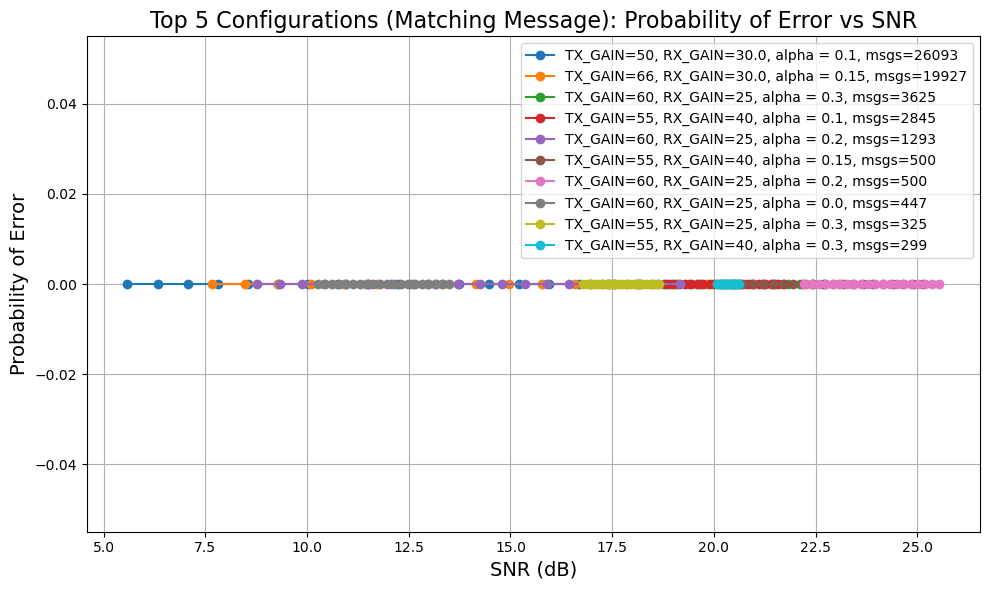

In [20]:

# --- Keep Only Top 5 Configurations ---
top_configs = sorted_configs[:10]
# [config for i, config in enumerate(sorted_configs[:7]) if i not in (2,4, 6)]

# --- Plot ---
plt.figure(figsize=(10, 6))

for config_json, data in top_configs:
    if data['total_messages'] < 10:
        continue  # Skip very small groups

    success_snrs = np.array(data['success_snrs'])

    min_snr = success_snrs.min()
    max_snr = success_snrs.max()
    bins = np.linspace(min_snr, max_snr, n_bins + 1)

    # Create histogram of successes
    success_hist, _ = np.histogram(success_snrs, bins=bins)

    # Here, because **all** messages are successes (no MAC to check failure in this case),
    # so total = success_hist
    total_hist = success_hist

    with np.errstate(divide='ignore', invalid='ignore'):
        # Probability of Error = 1 - (success / total) = 0 here normally
        error_prob = np.where(total_hist > 0, 1 - (success_hist / total_hist), 0)

    snr_points = (bins[:-1] + bins[1:]) / 2

    config = json.loads(config_json)
    label = f"TX_GAIN={config.get('TX_GAIN', 'N/A')}, RX_GAIN={config.get('RX_GAIN', 'N/A')}, alpha = {config.get('ALPHA', 'N/A')}, msgs={data['total_messages']}"

    plt.plot(snr_points, error_prob, marker='o', label=label)

# --- Final Plot Settings ---
plt.xlabel('SNR (dB)', fontsize=14)
plt.ylabel('Probability of Error', fontsize=14)
plt.title('Top 5 Configurations (Matching Message): Probability of Error vs SNR', fontsize=16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


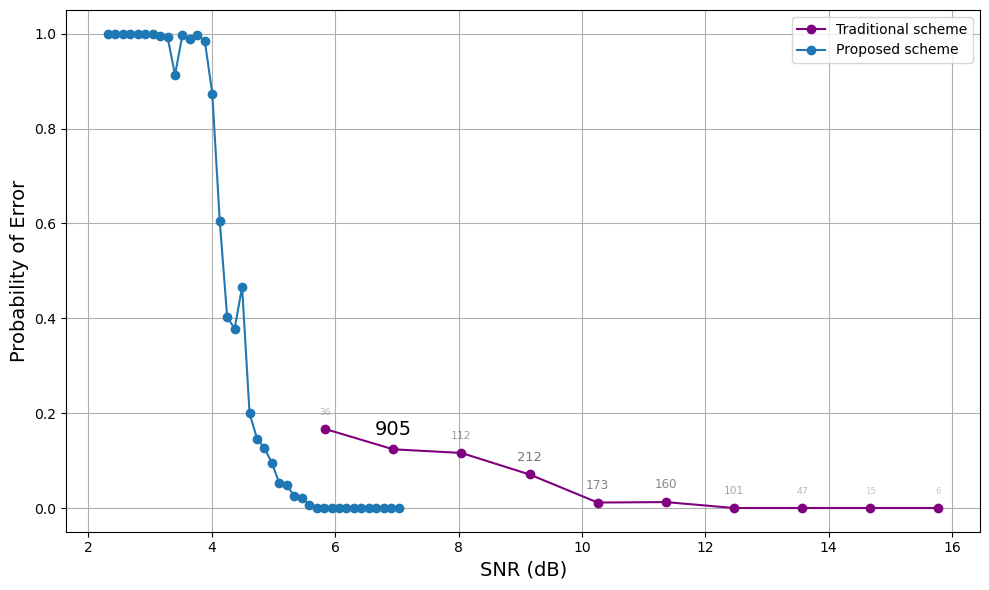

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient

# --- Connect to MongoDB ---
client = MongoClient('mongodb://localhost:27017/')
db = client['MAC_1D']

dest1d_col = db['Destination, phase_1']

# --- Settings ---
TARGET_MAC = '3776b3b21e2b54891a0731a27165ff9fbfed670657998d1d37acec5b41daedb2'
n_bins = 10  # Number of SNR bins

# --- Load Documents ---
docs = list(dest1d_col.find({}))

# --- Collect (SNR, success/failure) for each message ---
success_snrs = []
fail_snrs = []

for doc in docs:
    snr = doc.get('SNR')
    mac = doc.get('MAC')
    if snr is None or mac is None:
        continue

    if mac == TARGET_MAC:
        success_snrs.append(snr)
    else:
        fail_snrs.append(snr)

success_snrs = np.array(success_snrs)
fail_snrs = np.array(fail_snrs)

# --- Create SNR bins ---
all_snrs = np.concatenate((success_snrs, fail_snrs))
if len(all_snrs) == 0:
    raise ValueError("No valid SNR data found!")

min_snr = all_snrs.min()
max_snr = all_snrs.max()
bins = np.linspace(min_snr, max_snr, n_bins + 1)

# --- Calculate Histograms ---
success_hist, _ = np.histogram(success_snrs, bins=bins)
fail_hist, _ = np.histogram(fail_snrs, bins=bins)
total_hist = success_hist + fail_hist

# --- Calculate Error Probability ---
with np.errstate(divide='ignore', invalid='ignore'):
    error_prob = np.where(total_hist > 0, fail_hist / total_hist, 0)

snr_points_2 = (bins[:-1] + bins[1:]) / 2

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(snr_points_2, error_prob, marker='o', label='Traditional scheme', color='purple')

plt.plot(snr_points, average_error_prob, marker='o', label='Proposed scheme')



# Annotate each point with total number of packets
for x, y, count in zip(snr_points_2, error_prob, total_hist):
    if count == 0:
        continue

    min_fontsize = 6
    max_fontsize = 14
    min_alpha = 0.2
    max_alpha = 1.0
    scale_factor = 500  # Adjust based on your dataset

    fontsize = min(max(min_fontsize, (count / scale_factor) * (max_fontsize - min_fontsize) + min_fontsize), max_fontsize)
    alpha = min(max(min_alpha, (count / scale_factor) * (max_alpha - min_alpha) + min_alpha), max_alpha)

    plt.annotate(
        str(count),
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=fontsize,
        alpha=alpha
    )

# --- Final Plot Settings ---
plt.xlabel('SNR (dB)', fontsize=14)
plt.ylabel('Probability of Error', fontsize=14)
# plt.title('Average Probability of Error vs SNR (Destination Phase 1 - MAC_1D)', fontsize=16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pymongo


# Connect to the MongoDB, change the connection string per your MongoDB environment
conn = pymongo.MongoClient("mongodb://10.29.162.146:27017")
db = conn['MAC_SC']
collection_dest_phase1 = db['destination, phase_1']
collection_dest_phase2 = db['destination, phase_2']
collection_relay = db['relay, phase_1']

conf = conn['config']['config'].find_one()

In [ ]:
from datetime import datetime, timedelta

# Calculate the timestamp for 8 AM today
start_of_today = datetime.now().replace(hour=8, minute=45, second=0, microsecond=0).timestamp()

# Query records added from 8 AM today
total_dest_1 = collection_dest_phase1.count_documents(filter={'time': {'$gte': start_of_today}})
Correctly_received = collection_dest_phase1.count_documents(filter={'message': conf['PAYLOAD'],'time': {'$gte': start_of_today}})

print(f"Total dest pahse 1: {total_dest_1}, Correctly received: {Correctly_received}")

In [ ]:
total_realy = collection_relay.count_documents(filter={'time': {'$gte': start_of_today}})
Correctly_received = collection_relay.count_documents(filter={'$expr': {'$eq': ['$message', '$config.PAYLOAD']}, 'time': {'$gte': start_of_today}})

print(f"Total relay: {total_realy}, Correctly received: {Correctly_received}")

In [ ]:
total_dest_2 = collection_dest_phase2.count_documents(filter={'time': {'$gte': start_of_today}})
Correctly_received = collection_dest_phase2.count_documents(filter={'$expr': {'$eq': ['$message', '$config.PAYLOAD']}, 'time': {'$gte': start_of_today}})
dest_phase_2_itegrity_verified = collection_dest_phase2.count_documents(filter={'integrity':True, 'time': {'$gte': start_of_today}})
dest_phase_2_tag_correctly_received = collection_dest_phase2.count_documents(filter={'MAC': '023c03d8dfd3e9f5ba101ac681ec00d01c727428a1a5969ae817120958045b74', 'time': {'$gte': start_of_today}})

print(f"Total dest pahse 2: {total_dest_2}, Correctly received: {Correctly_received}, integrity verified: {dest_phase_2_itegrity_verified}, tag correctly received: {dest_phase_2_tag_correctly_received}")

In [ ]:
filter_criteria = {'integrity':True}
pipeline = [{"$match": filter_criteria}, {"$group": {"_id":None, "average_value":{"$avg": "$SNR"}}}]
list(collection_relay.aggregate(pipeline))

In [ ]:
filter_criteria = {'integrity':True}
pipeline = [{"$match": filter_criteria}, {"$group": {"_id":None, "average_value":{"$avg": "$SNR"}}}]
list(collection_dest_phase2.aggregate(pipeline))

In [ ]:
filter_criteria = {'integrity':False}
pipeline = [{"$match": filter_criteria}, {"$group": {"_id":None, "average_value":{"$avg": "$SNR"}}}]
list(collection_dest_phase1.aggregate(pipeline))

In [ ]:
filter_criteria = {'integrity':False}
pipeline = [{"$match": filter_criteria}, {"$group": {"_id":None, "average_value":{"$avg": "$SNR"}}}]
list(collection_relay.aggregate(pipeline))

In [ ]:
filter_criteria = {'integrity':False}
pipeline = [{"$match": filter_criteria}, {"$group": {"_id":None, "average_value":{"$avg": "$SNR"}}}]
list(collection_dest_phase2.aggregate(pipeline))

In [ ]:
filter_criteria = {}
pipeline = [{"$match": filter_criteria}, {"$group": {"_id":None, "average_value":{"$avg": "$SNR"}}}]
list(collection_dest_phase1.aggregate(pipeline))

In [ ]:
filter_criteria = {  }
pipeline = [{"$match": filter_criteria}, {"$group": {"_id":None, "average_value":{"$avg": "$SNR"}}}]
list(collection_relay.aggregate(pipeline))

In [ ]:
filter_criteria = { }
pipeline = [{"$match": filter_criteria}, {"$group": {"_id":None, "average_value":{"$avg": "$SNR"}}}]
list(collection_dest_phase2.aggregate(pipeline))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Increase font sizes globally
plt.rcParams.update({
    'font.size': 14,         # Base font size
    'axes.titlesize': 16,    # Title font size
    'axes.labelsize': 14,    # Axis label font size
    'xtick.labelsize': 12,   # X-tick label font size
    'ytick.labelsize': 12,   # Y-tick label font size
    'legend.fontsize': 12,   # Legend font size
    'figure.titlesize': 18   # Figure title font size
})

# Use a pleasing matplotlib style.
plt.style.use('ggplot')

# ------------------------------
# Data Setup
# ------------------------------
# Direct communication (Destination Phase 1)
direct_total   = 19463
direct_correct = 2644

# Source-to-Relay
relay_total   = 19764
relay_correct = 19761

# Relay-to-Destination (Phase 2)
dest_total      = 19764
dest_correct    = 19750
dest_integrity  = 19414

# SNR values for each link
snr_values    = [6.97, 17.50, 13.82]
snr_channels  = ["Direct\n(Dest Phase 1)", "Source to Relay", "Relay to Dest\n(Phase 2)"]

# ------------------------------
# Figure 1: Transmission Performance Comparison
# ------------------------------
# Create a figure with two subplots (side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)

# --- Left subplot: Direct & Source-to-Relay (each with 2 bars) ---
channels = ["Direct\n(Dest Phase 1)", "Source to Relay"]
total_values   = [direct_total, relay_total]
effective_vals = [direct_correct, relay_correct]

x = np.arange(len(channels))
bar_width = 0.35

bars_total = ax1.bar(x - bar_width/2, total_values, bar_width, label='Total Attempted')
bars_eff   = ax1.bar(x + bar_width/2, effective_vals, bar_width, label='Correctly Received')

ax1.set_xticks(x)
ax1.set_xticklabels(channels)
ax1.set_xlabel('Communication Channel')
ax1.set_ylabel('Number of Transmissions')
ax1.set_title('Transmission Performance (Direct & Source-to-Relay)')
ax1.legend()

# Annotate bars in ax1
for bar in bars_total:
    height = bar.get_height()
    ax1.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=12)
for bar in bars_eff:
    height = bar.get_height()
    ax1.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=12)

ax1.grid(True, linestyle='--', alpha=0.7)

# --- Right subplot: Relay-to-Destination (Phase 2) with 3 bars ---
metrics   = ["Total", "Correct", "Integrity"]
dest_vals = [dest_total, dest_correct, dest_integrity]

x2 = np.arange(len(metrics))
bar_dest = ax2.bar(x2, dest_vals, width=0.6, color='skyblue')

ax2.set_xticks(x2)
ax2.set_xticklabels(metrics)
ax2.set_xlabel('Metrics')
ax2.set_ylabel('Number of Transmissions')
ax2.set_title('Transmission Performance for Relay-to-Dest (Phase 2)')
ax2.grid(True, linestyle='--', alpha=0.7)

# Annotate bars in ax2
for bar in bar_dest:
    height = bar.get_height()
    ax2.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

# ------------------------------
# Figure 2: SNR Comparison
# ------------------------------
fig2, ax3 = plt.subplots(figsize=(10, 6), dpi = 200)
bars_snr = ax3.bar(snr_channels, snr_values, width=0.6, color='lightcoral')

ax3.set_xlabel('Communication Channel')
ax3.set_ylabel('SNR (dB)')
ax3.set_title('Received SNR Comparison')
ax3.grid(True, linestyle='--', alpha=0.7)

# Annotate SNR bars
for bar in bars_snr:
    height = bar.get_height()
    ax3.annotate(f'{height:.2f} dB',
                 xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()
